# **Uvod**

Ovu temu sam odabrao jer mi je osobno bliska. Potres koji je 2020. godine pogodio Petrinju (moj rodni grad) i okolna mjesta bio je događaj koji je iz prve ruke pokazao koliko se u takvim situacijama brzo može promijeniti svakodnevica i koliko je teško procijeniti razmjere štete i rizika dok se sve još događa. Tad mi je postalo jasno koliko je važno imati informacije koje su brze, provjerljive i jasno prikazane, pogotovo kad se radi o sigurnosti ljudi i infrastrukture.

Zato sam htio napraviti projekt koji se bavi potresima kroz analizu podataka i prikaz rezultata na razumljiv način. Ideja mi je bila povezati ono što smo učili na kolegiju s nečim što ima stvarni kontekst i smisao, a ne raditi temu samo “reda radi”. Kroz projekt sam se fokusirao na obradu dostupnih podataka, njihovu analizu i vizualizaciju, kako bi se iz rezultata mogli izvući konkretni zaključci i lakše razumjeti utjecaj potresa na određeno područje.

Osim akademskog dijela, smatram da ovakav pristup može imati i praktičnu vrijednost, primjerice za bolju procjenu rizika, informiranje javnosti ili kao pomoć pri planiranju i donošenju odluka u kriznim situacijama.

# **1) Učitavanje biblioteka i postavke okruženja**

U ovoj ćeliji uvozim biblioteke koje koristim kroz cijelu bilježnicu (pandas, numpy/matplotlib, sqlite3, datetime, math). Također postavljam putanje do ulaznih/izlaznih datoteka kako bi ostatak koda bio uredniji i lakše prenosiv.

In [1]:
import json
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import math
import requests
from urllib.parse import quote
from pathlib import Path
from datetime import datetime, timezone



# **2) Obrada podataka o gradovima (GeoNames CSV)**

Ovdje učitavam CSV s podacima o gradovima (ID, država, naziv, populacija i koordinate). To mi je potrebno da kasnije mogu povezati svaki potres s najbližim naseljenim mjestom.
Također u ovom koraku sređujem podatke o gradovima (tipovi podataka, nedostajuće vrijednosti) i radim filtriranje prema populaciji kako bi pretraga bila brža i fokusirana na veća naselja.

In [2]:

RAW = Path("/content/data/raw")
RAW.mkdir(parents=True, exist_ok=True)
RAW

PosixPath('/content/data/raw')

In [19]:
url = "https://gist.githubusercontent.com/ofou/df09a6834a8421b4f376c875194915c9/raw/355eb56e164ddc3cd1a9467c524422cb674e71a9/country-capital-lat-long-population.csv"
out = RAW / "capitals.csv"

df = pd.read_csv(url)
df.to_csv(out, index=False)

out, df.head()


(PosixPath('/content/data/raw/capitals.csv'),
           Country           Capital City  Latitude  Longitude  Population  \
 0     Afghanistan                  Kabul   34.5289    69.1725     4011770   
 1         Albania        Tiranë (Tirana)   41.3275    19.8189      475577   
 2         Algeria  El Djazaïr  (Algiers)   36.7525     3.0420     2693542   
 3  American Samoa              Pago Pago  -14.2781  -170.7025       48526   
 4         Andorra       Andorra la Vella   42.5078     1.5211       22614   
 
   Capital Type  
 0      Capital  
 1      Capital  
 2      Capital  
 3      Capital  
 4      Capital  )

# **3) Učitavanje i parsiranje potresa (USGS GeoJSON)**

Ovdje učitavam USGS GeoJSON s potresima. Taj format sadrži listu “features” gdje svaki zapis predstavlja jedan potres s vremenom, magnitudom i koordinatama.

In [20]:
RAW = Path("/content/data/raw")

GEOJSON_PATH = RAW / "usgs_earthquakes.geojson"

# Check if the file exists, if not, download it
if not GEOJSON_PATH.exists():
    print("Downloading usgs_earthquakes.geojson...")
    geojson_url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson"
    response = requests.get(geojson_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(GEOJSON_PATH, "wb") as f:
        f.write(response.content)
    print("Download complete.")

obj = json.loads(GEOJSON_PATH.read_text(encoding="utf-8"))
print("Broj potresa u JSON file-u:", len(obj.get("features", [])))

Download complete.
Broj potresa u JSON file-u: 8699


# **4) Računanje udaljenosti i impact score**

U ovoj ćeliji iz GeoJSON-a izvlačim ključne podatke (ID, vrijeme, lat/lon, dubina, magnituda, lokacija) i spremam ih u DataFrame eq. Na kraju provjeravam rezultat s head().

In [22]:
rows = []
for f in obj.get("features", []):
    props = f.get("properties") or {}
    geom = f.get("geometry") or {}
    coords = geom.get("coordinates") or None
    if not coords or len(coords) < 2:
        continue

    t_ms = props.get("time")
    if t_ms is None:
        continue

    rows.append({
        "usgs_id": str(f.get("id")),
        "time": datetime.fromtimestamp(t_ms/1000, tz=timezone.utc).isoformat(),
        "lat": float(coords[1]),
        "lon": float(coords[0]),
        "depth_km": float(coords[2]) if len(coords) >= 3 and coords[2] is not None else None,
        "mag": float(props["mag"]) if props.get("mag") is not None else None,
        "place": props.get("place")
    })

eq = pd.DataFrame(rows).dropna(subset=["usgs_id","time","lat","lon"]).copy()

eq.head()

,usgs_id,time,lat,lon,depth_km,mag,place
0,ci41164791,2026-01-20T15:23:06.260000+00:00,33.883167,-116.192833,4.59,1.04,"18 km N of Indio, CA"
1,nc75298781,2026-01-20T15:20:38.610000+00:00,38.835835,-122.795830,1.63,0.44,"6 km WNW of Cobb, CA"
2,ak2026bkazie,2026-01-20T15:10:28.956000+00:00,61.228000,-147.764000,25.70,1.30,"64 km S of Glacier View, Alaska"
3,ci41164775,2026-01-20T15:08:29.460000+00:00,33.900833,-116.184667,2.89,1.19,"20 km N of Indio, CA"
4,nc75298771,2026-01-20T15:04:47.210000+00:00,36.561165,-121.130333,0.87,1.68,"3 km NNE of Pinnacles, CA"


In [23]:
cities = df.rename(columns={
    "Latitude": "lat",
    "Longitude": "lon",
    "Population": "population"
}).copy()

cities["lat"] = pd.to_numeric(cities["lat"], errors="coerce")
cities["lon"] = pd.to_numeric(cities["lon"], errors="coerce")
cities["population"] = pd.to_numeric(cities["population"], errors="coerce").fillna(0).astype(int)

cities = cities.dropna(subset=["lat", "lon"]).copy()
cities.insert(0, "geonameid", range(1, len(cities) + 1))

print("Broj gradova za pretragu:", len(cities))

Broj gradova za pretragu: 234


# **5) Pronalaženje najbližeg grada**

Ovdje definiram funkciju distance_km() koja računa udaljenost između dvije geografske točke u kilometrima. To mi treba za računanje udaljenosti potres–grad. U ovom koraku definiram jednostavnu metriku impact_score koja kombinira magnitudu potresa, populaciju grada i udaljenost. Metrika služi za rangiranje i usporedbu slučajeva, a ne kao službena procjena štete. Pripremam podatke o gradovima u liste i implementiram funkciju nearest_city_fast() koja za zadani potres vraća najbliži grad, udaljenost i populaciju.

In [24]:
R = 6371.0088

def distance_km(lat1, lon1, lat2, lon2):
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dl/2)**2
    return R * (2*math.atan2(math.sqrt(a), math.sqrt(1-a)))

def impact_score(mag, pop, dist):
    mag = 0.0 if mag is None else float(mag)
    return mag * math.log10(int(pop) + 1) / (dist + 1)

cities_lat = cities["lat"].to_list()
cities_lon = cities["lon"].to_list()
cities_id  = cities["geonameid"].to_list()
cities_pop = cities["population"].to_list()

def nearest_city_fast(eq_lat, eq_lon):
    best_i, best_dist = 0, float("inf")
    for i in range(len(cities_id)):
        d = distance_km(eq_lat, eq_lon, cities_lat[i], cities_lon[i])
        if d < best_dist:
            best_dist = d
            best_i = i
    return cities_id[best_i], best_dist, cities_pop[best_i]

print("Broj gradova za pretragu:", len(cities_id))


Broj gradova za pretragu: 234


# **6) Integracija potres–grad i izračun rezultata**

U ovom dijelu uzimam uzorak potresa (npr. prvih N) i za svaki nalazim najbliži grad te računam udaljenost i impact_score. Rezultate spremam u tablicu imp i prikazujem top 10 po impact score-u.

In [25]:
N = 300
eq_work = eq.head(N).copy()

imp_rows = []
for _, q in eq_work.iterrows():
    cid, dist, pop = nearest_city_fast(q["lat"], q["lon"])
    imp_rows.append({
        "earthquake_id": q["usgs_id"],
        "city_id": int(cid),
        "distance_km": float(dist),
        "impact_score": float(impact_score(q["mag"], pop, dist))
    })

imp = pd.DataFrame(imp_rows)
print("Integriranih redaka:", len(imp))
imp.sort_values("impact_score", ascending=False).head(10)


Integriranih redaka: 300


,earthquake_id,city_id,distance_km,impact_score
105,us7000rqsn,89,31.880839,0.637823
107,pr71505478,167,97.707694,0.145656
117,pr71505473,167,97.554830,0.135508
220,us7000rqt0,227,180.582210,0.114415
200,us7000rqqz,180,205.281252,0.112668
167,us7000rqrj,86,295.020592,0.096601
236,us7000rqqi,149,367.840374,0.076103
131,us7000rqsh,180,284.309400,0.073474
156,us7000rqrt,161,480.912904,0.068126
64,us7000rqte,136,549.322595,0.066634


# **7) Spremanje rezultata (SQLite i izvozi)**

U ovoj ćeliji spremam rezultate obrade u SQLite bazu kako bih kasnije mogao raditi SQL upite i provjeriti podatke bez ponovnog pokretanja cijele obrade. Prvo kreiram mapu /content/outputs (ako već ne postoji) i definiram putanju do baze project.sqlite. Zatim se spajam na bazu preko sqlite3.connect().

Nakon spajanja, tri DataFrame-a (eq, cities, imp) zapisujem u bazu kao tablice earthquakes, cities i impacts pomoću to_sql(). Parametar if_exists="replace" znači da će se tablica prepisati ako već postoji (da uvijek imam svježe rezultate), a index=False sprječava spremanje Pandas indeksa kao dodatnog stupca.

Na kraju zatvaram vezu (conn.close()) i ispisujem poruku s lokacijom baze kako bih odmah vidio da je datoteka uspješno kreirana i spremljena.

In [26]:
DB_DIR = Path("/content/outputs")
DB_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH = DB_DIR / "project.sqlite"
conn = sqlite3.connect(DB_PATH)

eq.to_sql("earthquakes", conn, if_exists="replace", index=False)
cities.to_sql("cities", conn, if_exists="replace", index=False)
imp.to_sql("impacts", conn, if_exists="replace", index=False)

conn.close()

print("Baza spremljena u:", DB_PATH.resolve())

Baza spremljena u: /content/outputs/project.sqlite


# **8) Vizualizacije grafova**

U ovoj ćeliji izrađujem 3 grafa i spremam ih u /content/outputs:

Histogram magnituda – prikazuje raspodjelu magnituda (eq["mag"], bez NaN) i sprema se kao hist_magnitudes.png.

Top 10 po impact score-u – sortiram imp po impact_score, uzimam 10 najvećih i spremam kao top10_impact.png.

Udaljenost vs. impact score – scatter graf (distance_km prema impact_score) i spremam kao scatter_distance_impact.png.

Na kraju se ispiše putanja mape gdje su grafovi spremljeni.

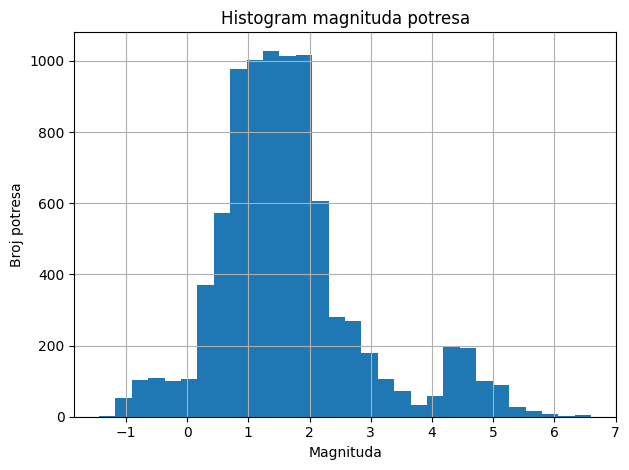

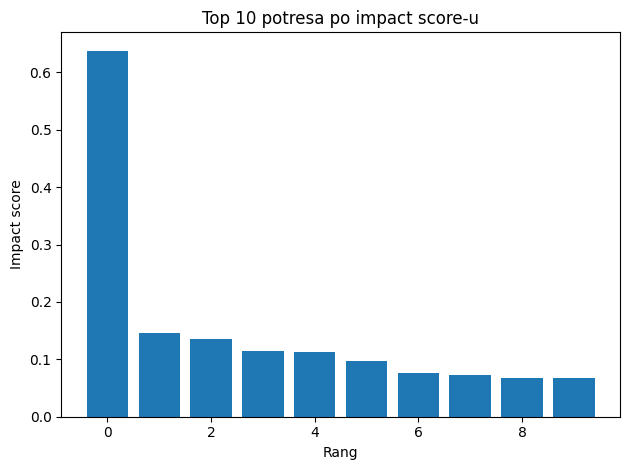

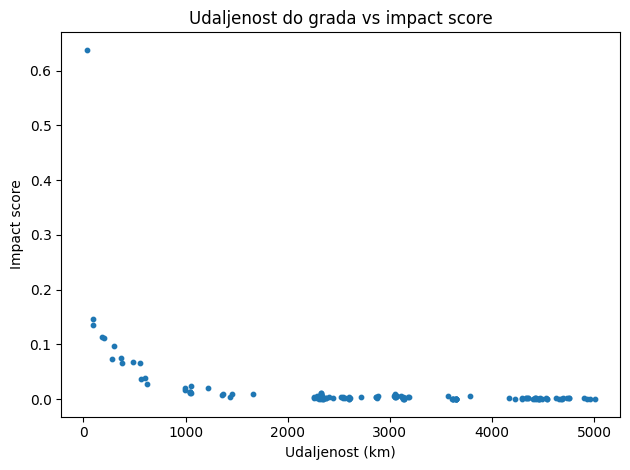

Grafovi spremljeni u: /content/outputs


In [27]:
OUT = Path("/content/outputs")

# 1) Histogram magnituda
plt.figure()
eq["mag"].dropna().hist(bins=30)
plt.title("Histogram magnituda potresa")
plt.xlabel("Magnituda")
plt.ylabel("Broj potresa")
plt.tight_layout()
plt.savefig(OUT / "hist_magnitudes.png", dpi=160)
plt.show()

# 2) Najvecih 10 impact scoreova
top = imp.sort_values("impact_score", ascending=False).head(10)
plt.figure()
plt.bar(range(len(top)), top["impact_score"])
plt.title("Top 10 potresa po impact score-u")
plt.xlabel("Rang")
plt.ylabel("Impact score")
plt.tight_layout()
plt.savefig(OUT / "top10_impact.png", dpi=160)
plt.show()

# 3) Udaljenost i impact
plt.figure()
plt.scatter(imp["distance_km"], imp["impact_score"], s=10)
plt.title("Udaljenost do grada vs impact score")
plt.xlabel("Udaljenost (km)")
plt.ylabel("Impact score")
plt.tight_layout()
plt.savefig(OUT / "scatter_distance_impact.png", dpi=160)
plt.show()

print("Grafovi spremljeni u:", OUT.resolve())

# **9) SQL upit (provjera rezultata iz baze)**

Ovdje se spajam na SQLite bazu i radim SQL JOIN između tablica impacts, earthquakes i cities kako bih dobio 10 zapisa s najvećim impact_score. Rezultat učitavam u DataFrame q i prikazujem ga kao provjeru da su podaci ispravno spremljeni i povezani.

In [13]:
conn = sqlite3.connect(DB_PATH)
q = pd.read_sql_query("""
SELECT i.impact_score, i.distance_km, e.mag, e.time, c."Capital City" as city, c.Country as country, c.population
FROM impacts i
JOIN earthquakes e ON e.usgs_id = i.earthquake_id
JOIN cities c ON c.geonameid = i.city_id
ORDER BY i.impact_score DESC
LIMIT 10
""", conn)
conn.close()
q

,impact_score,distance_km,mag,time,city,country,population
0,0.637823,31.880839,4.40,2026-01-20T09:31:16.972000+00:00,Basse-Terre,Guadeloupe,58397
1,0.145656,97.707694,2.25,2026-01-20T09:25:49.390000+00:00,San Juan,Puerto Rico,2454337
2,0.135508,97.554830,2.09,2026-01-20T08:53:20.550000+00:00,San Juan,Puerto Rico,2454337
3,0.114415,180.582210,4.40,2026-01-20T05:03:36.802000+00:00,Port Vila,Vanuatu,52690
4,0.112668,205.281252,5.10,2026-01-20T05:39:06.776000+00:00,Apia,Samoa,36066
5,0.096601,295.020592,4.40,2026-01-20T06:38:31.215000+00:00,Athínai (Athens),Greece,3155600
6,0.076103,367.840374,5.30,2026-01-20T04:39:05.417000+00:00,Nouméa,New Caledonia,197787
7,0.073474,284.309400,4.60,2026-01-20T08:18:20.296000+00:00,Apia,Samoa,36066
8,0.068126,480.912904,5.90,2026-01-20T07:21:58.634000+00:00,Port Moresby,Papua New Guinea,366862
9,0.066634,549.322595,5.00,2026-01-20T11:30:13.812000+00:00,Ciudad de México (Mexico City),Mexico,21580827


# **10) Izvoz integrirane tablice u CSV**

U ovom koraku spajam tablicu imp s detaljima o potresima (eq) i gradovima (cities) preko ID-eva, kako bih dobio jednu integriranu tablicu sa svim važnim podacima na jednom mjestu. Zatim je spremam kao CSV u /content/outputs, ispisujem putanju datoteke i prikazujem prvih nekoliko redaka kao provjeru.

In [14]:
OUT_CSV = OUT / "/content/outputs/integrirani_potresi_gradovi.csv"

integrirano = imp.merge(eq, left_on="earthquake_id", right_on="usgs_id", how="left") \
                 .merge(cities, left_on="city_id", right_on="geonameid", how="left",
                        suffixes=("_potres", "_grad"))

integrirano.to_csv(OUT_CSV, index=False)
print("Integrirani CSV spremljen:", OUT_CSV.resolve())
integrirano.head()


Integrirani CSV spremljen: /content/outputs/integrirani_potresi_gradovi.csv


,earthquake_id,city_id,distance_km,impact_score,usgs_id,time,lat_potres,lon_potres,depth_km,mag,place,geonameid,Country,Capital City,lat_grad,lon_grad,population,Capital Type
0,ak2026bkazie,87,4438.397402,0.001249,ak2026bkazie,2026-01-20T15:10:28.956000+00:00,61.228000,-147.764000,25.70,1.30,"64 km S of Glacier View, Alaska",87,Greenland,Nuuk (Godthåb),64.1835,-51.7216,18406,Capital
1,ci41164775,136,2329.589915,0.003745,ci41164775,2026-01-20T15:08:29.460000+00:00,33.900833,-116.184667,2.89,1.19,"20 km N of Indio, CA",136,Mexico,Ciudad de México (Mexico City),19.4273,-99.1419,21580827,Capital
2,nc75298771,136,2865.902643,0.004298,nc75298771,2026-01-20T15:04:47.210000+00:00,36.561165,-121.130333,0.87,1.68,"3 km NNE of Pinnacles, CA",136,Mexico,Ciudad de México (Mexico City),19.4273,-99.1419,21580827,Capital
3,ci41164743,136,2329.003243,0.002518,ci41164743,2026-01-20T14:40:52.870000+00:00,33.878500,-116.198500,3.23,0.80,"18 km N of Indio, CA",136,Mexico,Ciudad de México (Mexico City),19.4273,-99.1419,21580827,Capital
4,ci41164727,136,2328.828910,0.003211,ci41164727,2026-01-20T14:38:36.340000+00:00,33.901000,-116.173833,4.41,1.02,"20 km N of Indio, CA",136,Mexico,Ciudad de México (Mexico City),19.4273,-99.1419,21580827,Capital


# **Kritički osvrt**

Ovaj projekt je praktično izvediv jer koristi javno dostupne izvore podataka i može se pokrenuti kao jedna Jupyter/Colab bilježnica bez posebne infrastrukture. Prednost je što je cijeli postupak ponovljiv: promjenom ulaznih datoteka (drugi period, drugo područje) mogu dobiti nove rezultate bez ručnog rada. Također je korisno što se rezultati spremaju u SQLite i CSV, pa se mogu dalje analizirati i izvan Colaba (npr. u Excelu ili kroz SQL upite).

Međutim, treba naglasiti da je model namjerno pojednostavljen. impact_score je metrika koju sam definirao za rangiranje i usporedbu, ali ona ne predstavlja stvarnu procjenu štete. Stvarna razina utjecaja ovisi o puno dodatnih faktora koje ovdje ne uzimam u obzir (kvaliteta gradnje, tip tla, dubina potresa, broj naselja u blizini, gustoća naseljenosti, itd.). Zbog toga rezultate treba tumačiti kao indikaciju koji su događaji “zanimljivi” za daljnji pregled, a ne kao točnu procjenu posljedica.

Još jedno ograničenje je način traženja najbližeg grada. Trenutno se za svaki potres prolazi kroz sve filtrirane gradove (linearna pretraga), što je prihvatljivo za manji uzorak i veće gradove, ali za veće skupove podataka postaje sporo. U ozbiljnijoj primjeni to bi se rješavalo prostornim indeksiranjem (npr. KDTree/BallTree) ili korištenjem geospacijalne baze podataka.

Unatoč ograničenjima, projekt ima smisla kao početni prototip i demonstracija rada s podacima. Može poslužiti za brzu analizu i vizualni pregled, pogotovo kao edukativni primjer. Ako bi se koristio u praksi (npr. za brzu procjenu prioriteta nakon potresa), trebalo bi ga proširiti preciznijim parametrima i validirati rezultate na stvarnim podacima o štetama, kako bi zaključci bili pouzdaniji.

# ***Zaključak***

U ovom projektu sam izradio Colab bilježnicu koja od ulaznih podataka dolazi do konkretnih rezultata: tablica s potresima, povezivanja potresa s najbližim gradom, izračuna udaljenosti i pokazatelja utjecaja te prikaza kroz grafove. Sve je organizirano tako da se bilježnica može pokrenuti redom i svaki korak se može provjeriti odmah nakon izvođenja.

Kroz rad sam najviše dobio osjećaj kako izgleda obrada podataka u praksi podaci nisu uvijek “čisti”, pa je trebalo paziti na nedostajuće vrijednosti, formate i tipove podataka. Nakon toga, kad su podaci sređeni, bilo je jednostavnije napraviti spajanja tablica i dobiti pregledne rezultate. Dodatno mi je korisno bilo spremanje u bazu i izvoz u CSV jer time rezultati ostaju dostupni i bez ponovnog pokretanja cijelog postupka.

Na kraju mogu reći da je cilj ostvaren: napravio sam rješenje koje na razumljiv način prikazuje podatke o potresima i daje rangiranje događaja prema jednostavnom pokazatelju. Tema mi je bila važna i zbog osobne povezanosti s potresom u Petrinji 2020. godine, pa mi je bilo bitno da projekt ima smisao i izvan samog zadatka i da ostavi osnovu za daljnju nadogradnju.